<a href="https://colab.research.google.com/github/kvarun2300/Bird-Species-Observation-Analysis/blob/main/Bird_Species_Observation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# List your Excel files
files = ["/content/sample_data/Bird_Forest.XLSX", "/content/sample_data/Bird_Grassland.XLSX"]

all_data = []

for file in files:
    # Read all sheets from workbook
    sheets_dict = pd.read_excel(file, sheet_name=None)

    for sheet_name, df in sheets_dict.items():
        df["Source_File"] = file          # optional: track origin
        df["Sheet_Name"] = sheet_name     # optional: track admin unit
        all_data.append(df)

# Merge everything into one DataFrame
final_df = pd.concat(all_data, ignore_index=True)

# Save output if needed
final_df.to_csv("merged_bird_data.csv", index=False)

print(final_df.shape)

/tmp/ipykernel_1322/3530273173.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(all_data, ignore_index=True)


(17077, 33)


In [3]:
import pandas as pd
import numpy as np

df = final_df.copy()

# ---------------------------
# 1. Standardize column names
# ---------------------------
df.columns = df.columns.str.strip().str.lower()

# ---------------------------
# 2. Handle missing values
# ---------------------------

# Drop rows where species is missing (critical)
df = df.dropna(subset=["common_name", "scientific_name"])

# Fill environmental missing values
df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")
df["humidity"] = pd.to_numeric(df["humidity"], errors="coerce")

df["temperature"].fillna(df["temperature"].median(), inplace=True)
df["humidity"].fillna(df["humidity"].median(), inplace=True)

# Fill categorical missing values
df["sky"].fillna("Unknown", inplace=True)
df["wind"].fillna("Unknown", inplace=True)
df["disturbance"].fillna("None", inplace=True)

# ---------------------------
# 3. Standardize boolean fields
# ---------------------------
df["flyover_observed"] = df["flyover_observed"].astype(str).str.upper().map({
    "TRUE": 1, "FALSE": 0
})

# ---------------------------
# 4. Standardize time + date
# ---------------------------
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce").dt.time
df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce").dt.time

# ---------------------------
# 5. Normalize distance
# ---------------------------
df["distance"] = df["distance"].str.replace("Meters", "").str.strip()
df["distance"] = df["distance"].replace({
    "<= 50": "0-50",
    "> 50": "50+"
})

/tmp/ipykernel_1322/917107370.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["temperature"].fillna(df["temperature"].median(), inplace=True)
/tmp/ipykernel_1322/917107370.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

### Filter relevant columns and finalize data types

Based on the typical requirements for bird observation analysis, we'll select columns related to species identification, environmental conditions, temporal data, and observational metrics. We'll also ensure data types are optimized.

In [23]:
# Inspect current columns and their data types
print(df.info())

# List of columns to keep for analysis
selected_columns = [
    'common_name', 'scientific_name',
    'admin_unit_code', 'sub_unit_code', 'site_name', 'plot_name', 'location_type',
    'year', 'date', 'start_time', 'end_time',
    'temperature', 'humidity', 'sky', 'wind', 'disturbance', 'distance',
    'flyover_observed',
    'source_file', 'sheet_name', 'observer', 'visit',
    'pif_watchlist_status', 'regional_stewardship_status', 'aou_code' # Added missing columns
]

# Filter the DataFrame to keep only the selected columns
df_cleaned = df[selected_columns].copy()

# Convert categorical columns to 'category' dtype for memory efficiency and better analysis
for col in ['admin_unit_code', 'sub_unit_code', 'site_name', 'plot_name', 'location_type',
            'sky', 'wind', 'disturbance', 'distance',
            'source_file', 'sheet_name', 'common_name', 'scientific_name', 'observer', 'visit',
            'pif_watchlist_status', 'regional_stewardship_status', 'aou_code']:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].astype('category')

# Display the first few rows of the cleaned DataFrame
display(df_cleaned.head())
print(df_cleaned.info()) # This will show the updated info with 'visit' column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   admin_unit_code              17077 non-null  object        
 1   sub_unit_code                722 non-null    object        
 2   site_name                    8546 non-null   object        
 3   plot_name                    17077 non-null  object        
 4   location_type                17077 non-null  object        
 5   year                         17077 non-null  object        
 6   date                         17077 non-null  datetime64[ns]
 7   start_time                   0 non-null      datetime64[ns]
 8   end_time                     0 non-null      datetime64[ns]
 9   observer                     17077 non-null  object        
 10  visit                        17077 non-null  object        
 11  interval_length              17077 non-nu

,common_name,scientific_name,admin_unit_code,sub_unit_code,site_name,plot_name,location_type,year,date,start_time,...,disturbance,distance,flyover_observed,source_file,sheet_name,observer,visit,pif_watchlist_status,regional_stewardship_status,aou_code
0,Eastern Towhee,Pipilo erythrophthalmus,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,NaT,...,No effect on count,0-50,0,/content/sample_data/Bird_Forest.XLSX,ANTI,Elizabeth Oswald,1,False,True,EATO
1,White-breasted Nuthatch,Sitta carolinensis,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,NaT,...,No effect on count,0-50,0,/content/sample_data/Bird_Forest.XLSX,ANTI,Elizabeth Oswald,1,False,False,WBNU
2,Red-bellied Woodpecker,Melanerpes carolinus,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,NaT,...,No effect on count,50 - 100,0,/content/sample_data/Bird_Forest.XLSX,ANTI,Elizabeth Oswald,1,False,False,RBWO
3,Orchard Oriole,Icterus spurius,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,NaT,...,No effect on count,0-50,0,/content/sample_data/Bird_Forest.XLSX,ANTI,Elizabeth Oswald,1,False,False,OROR
4,Northern Mockingbird,Mimus polyglottos,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,NaT,...,No effect on count,0-50,0,/content/sample_data/Bird_Forest.XLSX,ANTI,Elizabeth Oswald,1,False,False,NOMO


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   common_name                  17077 non-null  category      
 1   scientific_name              17077 non-null  category      
 2   admin_unit_code              17077 non-null  category      
 3   sub_unit_code                722 non-null    category      
 4   site_name                    8546 non-null   category      
 5   plot_name                    17077 non-null  category      
 6   location_type                17077 non-null  category      
 7   year                         17077 non-null  object        
 8   date                         17077 non-null  datetime64[ns]
 9   start_time                   0 non-null      datetime64[ns]
 10  end_time                     0 non-null      datetime64[ns]
 11  temperature                  17077 non-nu

### Temporal Analysis

This section focuses on analyzing temporal patterns in bird sightings, including seasonal trends and (where possible) observation times.

In [39]:
# Extract temporal features
df_cleaned['month'] = df_cleaned['date'].dt.month
df_cleaned['day_of_week'] = df_cleaned['date'].dt.dayofweek # Monday=0, Sunday=6
df_cleaned['year'] = pd.to_numeric(df_cleaned['year'], errors='coerce')

# Display the updated DataFrame info to confirm new columns and types
print(df_cleaned.info())

display(df_cleaned.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   common_name                  17077 non-null  category      
 1   scientific_name              17077 non-null  category      
 2   admin_unit_code              17077 non-null  category      
 3   sub_unit_code                722 non-null    category      
 4   site_name                    8546 non-null   category      
 5   plot_name                    17077 non-null  category      
 6   location_type                17077 non-null  category      
 7   year                         17077 non-null  int64         
 8   date                         17077 non-null  datetime64[ns]
 9   start_time                   0 non-null      datetime64[ns]
 10  end_time                     0 non-null      datetime64[ns]
 11  temperature                  17077 non-nu

,common_name,scientific_name,admin_unit_code,sub_unit_code,site_name,plot_name,location_type,year,date,start_time,...,flyover_observed,source_file,sheet_name,observer,visit,pif_watchlist_status,regional_stewardship_status,aou_code,month,day_of_week
0,Eastern Towhee,Pipilo erythrophthalmus,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,NaT,...,0,/content/sample_data/Bird_Forest.XLSX,ANTI,Elizabeth Oswald,1,False,True,EATO,5,1
1,White-breasted Nuthatch,Sitta carolinensis,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,NaT,...,0,/content/sample_data/Bird_Forest.XLSX,ANTI,Elizabeth Oswald,1,False,False,WBNU,5,1
2,Red-bellied Woodpecker,Melanerpes carolinus,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,NaT,...,0,/content/sample_data/Bird_Forest.XLSX,ANTI,Elizabeth Oswald,1,False,False,RBWO,5,1
3,Orchard Oriole,Icterus spurius,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,NaT,...,0,/content/sample_data/Bird_Forest.XLSX,ANTI,Elizabeth Oswald,1,False,False,OROR,5,1
4,Northern Mockingbird,Mimus polyglottos,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,NaT,...,0,/content/sample_data/Bird_Forest.XLSX,ANTI,Elizabeth Oswald,1,False,False,NOMO,5,1


#### Monthly Trends in Bird Sightings

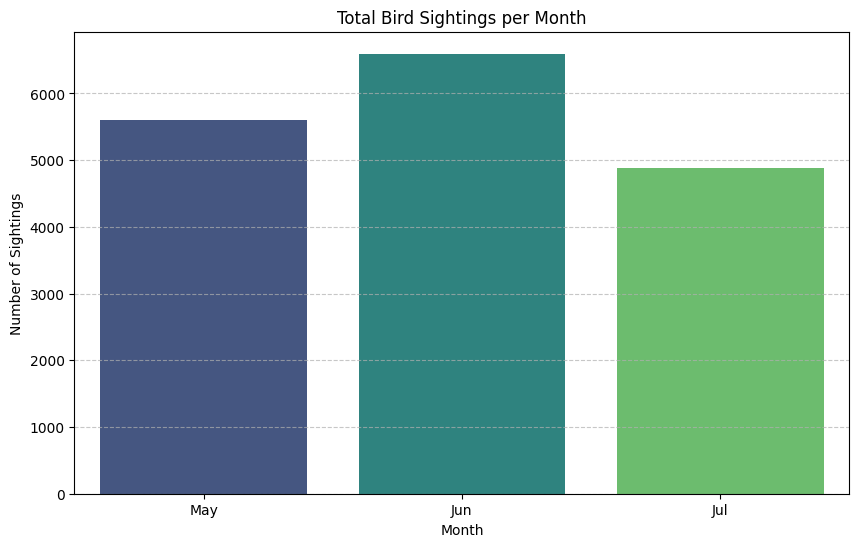

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count sightings per month
monthly_sightings = df_cleaned.groupby('month', observed=True).size().reset_index(name='count')

# Map month numbers to names for better readability
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sightings['month_name'] = monthly_sightings['month'].map(lambda x: month_names[x-1])

plt.figure(figsize=(10, 6))
sns.barplot(x='month_name', y='count', data=monthly_sightings, palette='viridis', hue='month_name', legend=False)
plt.title('Total Bird Sightings per Month')
plt.xlabel('Month')
plt.ylabel('Number of Sightings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Observation Time Analysis (Addressing Missing Data)

It appears that the `start_time` and `end_time` columns are entirely null (all `NaT` values) in the dataset after the initial cleaning. This means we currently do not have valid data to analyze bird activity based on specific observation times. If time-specific data is crucial for further analysis, it would require revisiting the data source or initial data ingestion steps to ensure these fields are correctly parsed.

### Spatial Analysis

This section focuses on analyzing bird sightings based on their geographical locations, specifically `location_type` and `plot_name`.

#### Location Type Insights: Biodiversity Hotspots

This analysis will group the data by `location_type` (e.g., Forest, Grassland) and count the number of unique bird species found in each to identify potential biodiversity hotspots.

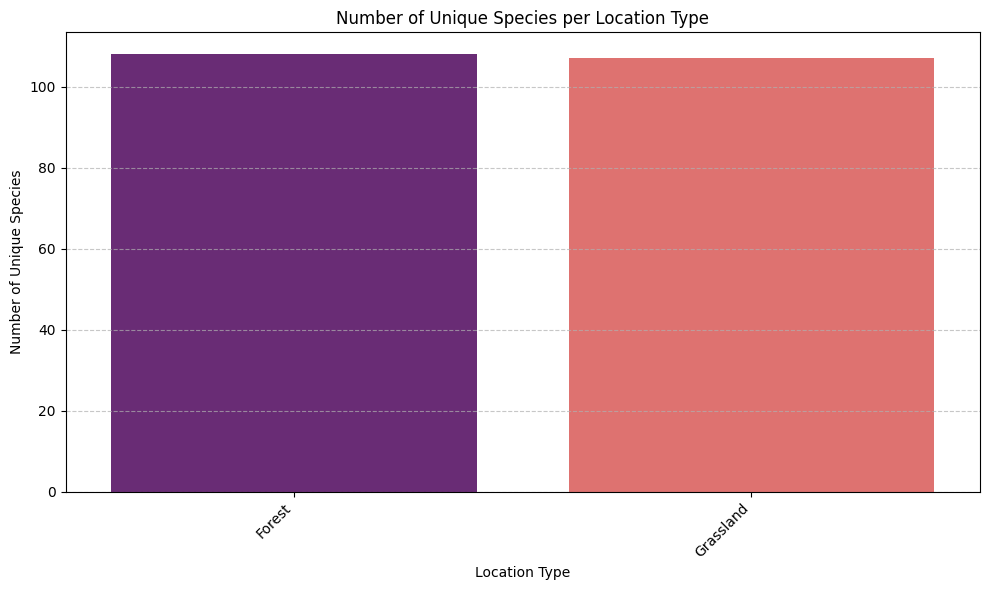

In [41]:
# Group by location_type and count unique species
biodiversity_by_location = df_cleaned.groupby('location_type', observed=True)['common_name'].nunique().reset_index(name='unique_species_count')

plt.figure(figsize=(10, 6))
sns.barplot(x='location_type', y='unique_species_count', data=biodiversity_by_location, palette='magma', hue='location_type', legend=False)
plt.title('Number of Unique Species per Location Type')
plt.xlabel('Location Type')
plt.ylabel('Number of Unique Species')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Plot-Level Analysis: Species Diversity per Plot

Here, we will compare observations across different `plot_name` values to identify which specific plots attract a greater number of unique bird species. I will display the top 10 plots by species count.

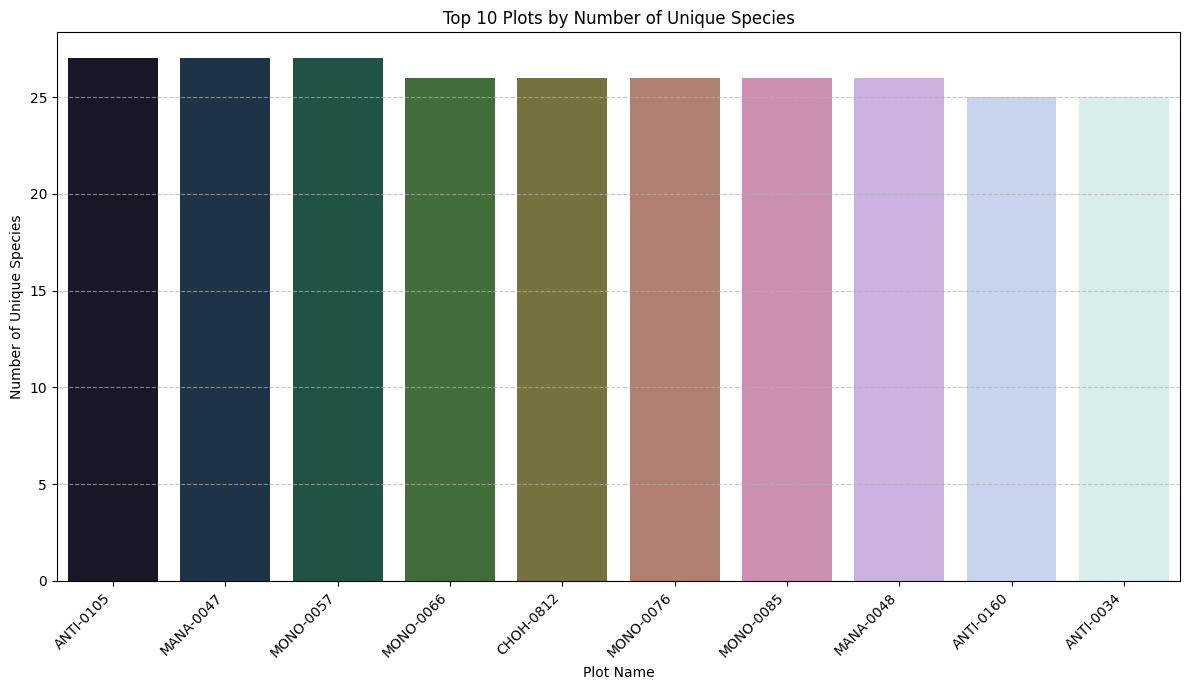

In [57]:
# Group by plot_name and count unique species
species_per_plot = df_cleaned.groupby('plot_name', observed=True)['common_name'].nunique().reset_index(name='unique_species_count')

# Sort and take top 10
species_per_plot_sorted = species_per_plot.sort_values(by='unique_species_count', ascending=False).head(10).copy()

# Convert to string to prevent unused categorical levels from breaking the plot
species_per_plot_sorted['plot_name'] = species_per_plot_sorted['plot_name'].astype(str)

plt.figure(figsize=(12, 7))
sns.barplot(x='plot_name', y='unique_species_count', data=species_per_plot_sorted, palette='cubehelix', hue='plot_name', legend=False)
plt.title('Top 10 Plots by Number of Unique Species')
plt.xlabel('Plot Name')
plt.ylabel('Number of Unique Species')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Species Analysis

This section focuses on the diversity, activity patterns, and demographic aspects of the observed bird species.

#### Diversity Metrics: Unique Species Count and Distribution

We will count the total number of unique bird species observed and then analyze their distribution across different `location_type` values to understand where specific species are more prevalent.

Total unique bird species observed: 127


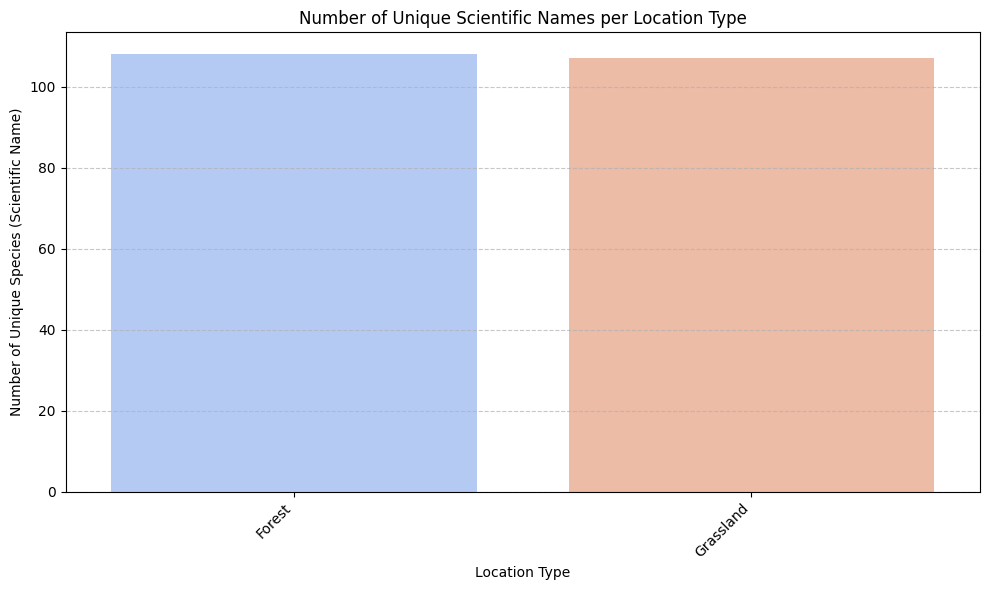

In [43]:
# Total number of unique species
total_unique_species = df_cleaned['scientific_name'].nunique()
print(f"Total unique bird species observed: {total_unique_species}")

# Unique species per location type (similar to previous, but explicitly for scientific_name)
species_by_location_type = df_cleaned.groupby('location_type', observed=True)['scientific_name'].nunique().reset_index(name='unique_scientific_names')

plt.figure(figsize=(10, 6))
sns.barplot(x='location_type', y='unique_scientific_names', data=species_by_location_type, palette='coolwarm', hue='location_type', legend=False)
plt.title('Number of Unique Scientific Names per Location Type')
plt.xlabel('Location Type')
plt.ylabel('Number of Unique Species (Scientific Name)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Activity Patterns and Sex Ratio Analysis (Missing Data)

Upon reviewing the `df_cleaned` DataFrame, it appears that the columns `interval_length`, `id_method`, and `sex` were not included when the DataFrame was filtered. Therefore, we cannot perform the requested analysis on activity patterns and sex ratio with the current `df_cleaned`.

If you would like to proceed with analyzing these metrics, please let me know. We would need to revisit the data cleaning and filtering step (cell `4f457af3`) to ensure these columns are retained in the `df_cleaned` DataFrame.

### Environmental Conditions Analysis

#### Weather Correlation: Temperature and Humidity

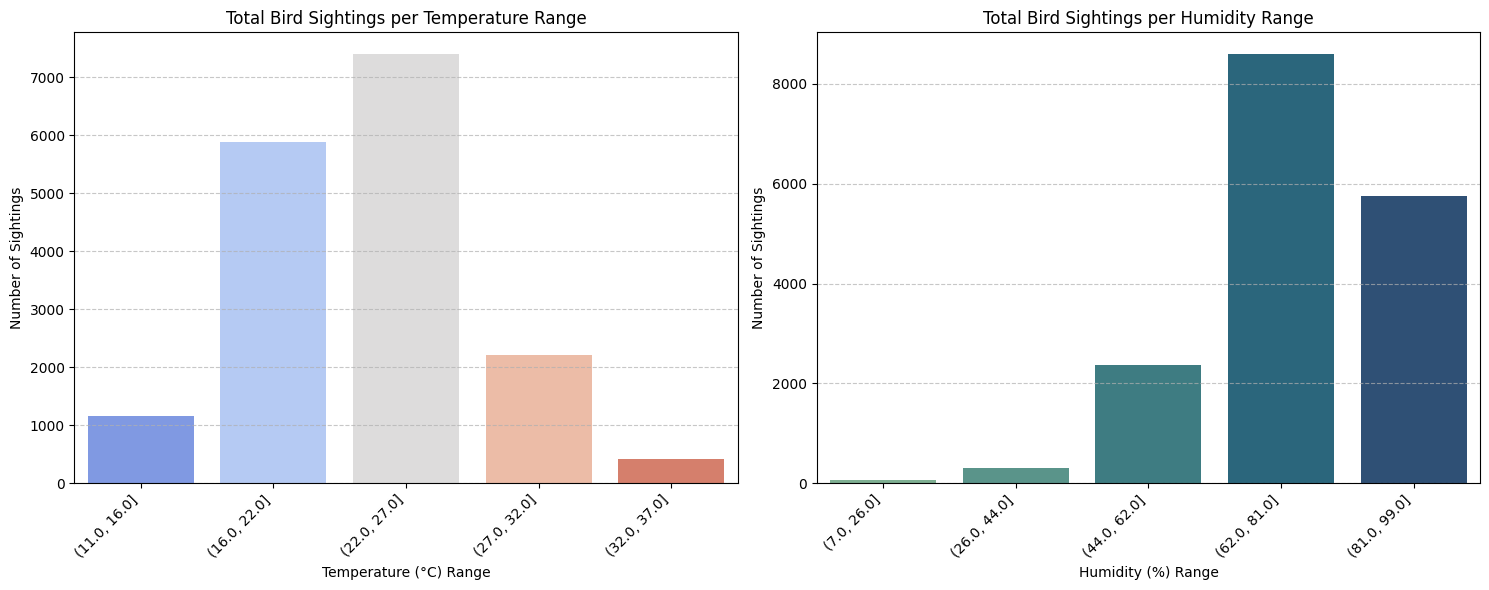

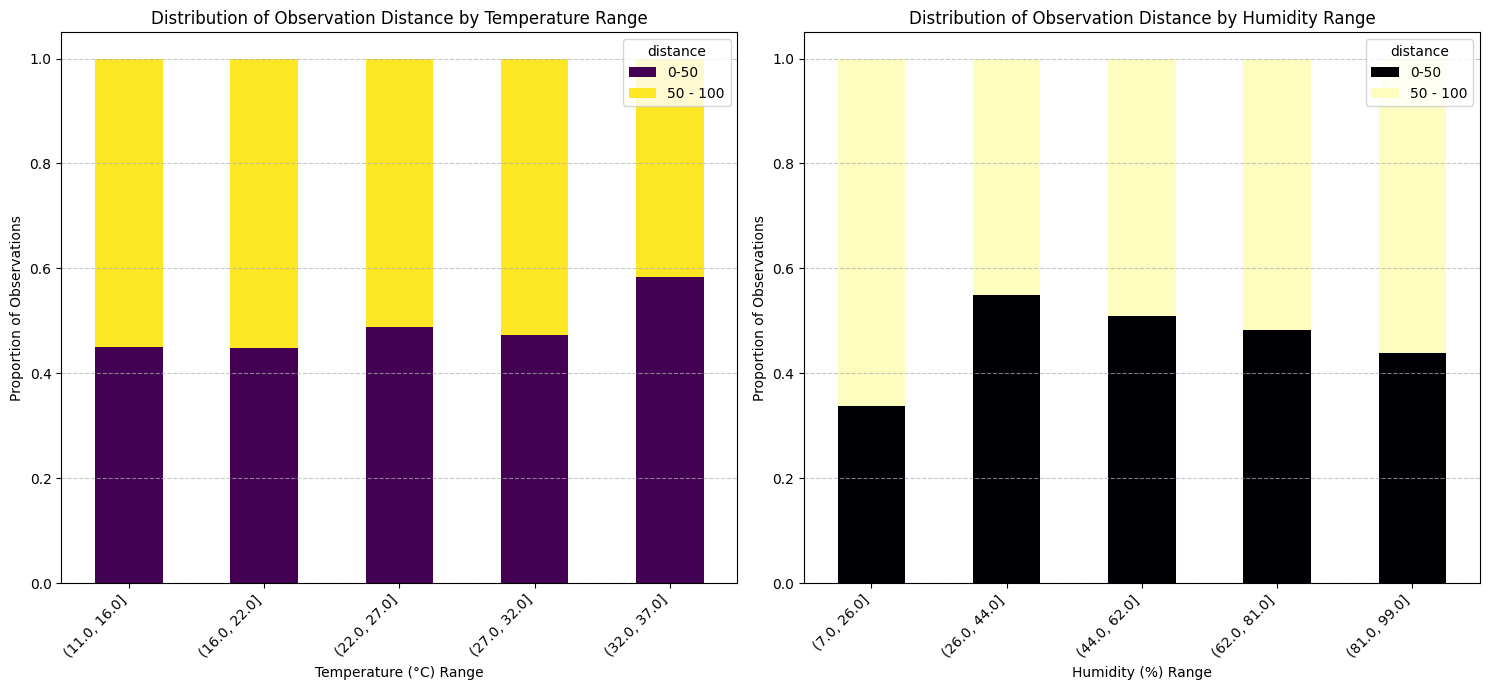

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create bins for temperature and humidity for clearer visualization
# Use larger bins or fewer bins to reduce granularity if needed
# Here, we'll create 5 bins for both for demonstration.
num_bins = 5 # You can adjust this number

df_cleaned['temp_bin'] = pd.cut(df_cleaned['temperature'], bins=num_bins, precision=0)
df_cleaned['humidity_bin'] = pd.cut(df_cleaned['humidity'], bins=num_bins, precision=0)

plt.figure(figsize=(15, 6))

# Plot 1: Bird Sightings by Temperature Range
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
temp_sightings = df_cleaned.groupby('temp_bin', observed=True).size().reset_index(name='count')
sns.barplot(x='temp_bin', y='count', data=temp_sightings, palette='coolwarm', hue='temp_bin', legend=False)
plt.title('Total Bird Sightings per Temperature Range')
plt.xlabel('Temperature (°C) Range')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Bird Sightings by Humidity Range
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
humidity_sightings = df_cleaned.groupby('humidity_bin', observed=True).size().reset_index(name='count')
sns.barplot(x='humidity_bin', y='count', data=humidity_sightings, palette='crest', hue='humidity_bin', legend=False)
plt.title('Total Bird Sightings per Humidity Range')
plt.xlabel('Humidity (%) Range')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plotting distribution of 'distance' for temperature bins
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
distance_temp_crosstab = pd.crosstab(df_cleaned['temp_bin'], df_cleaned['distance'], normalize='index')
distance_temp_crosstab.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Distribution of Observation Distance by Temperature Range')
plt.xlabel('Temperature (°C) Range')
plt.ylabel('Proportion of Observations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plotting distribution of 'distance' for humidity bins
plt.subplot(1, 2, 2)
distance_humidity_crosstab = pd.crosstab(df_cleaned['humidity_bin'], df_cleaned['distance'], normalize='index')
distance_humidity_crosstab.plot(kind='bar', stacked=True, colormap='magma', ax=plt.gca())
plt.title('Distribution of Observation Distance by Humidity Range')
plt.xlabel('Humidity (%) Range')
plt.ylabel('Proportion of Observations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Drop the temporary bin columns
df_cleaned = df_cleaned.drop(columns=['temp_bin', 'humidity_bin'], errors='ignore')

#### Weather Correlation: Sky and Wind

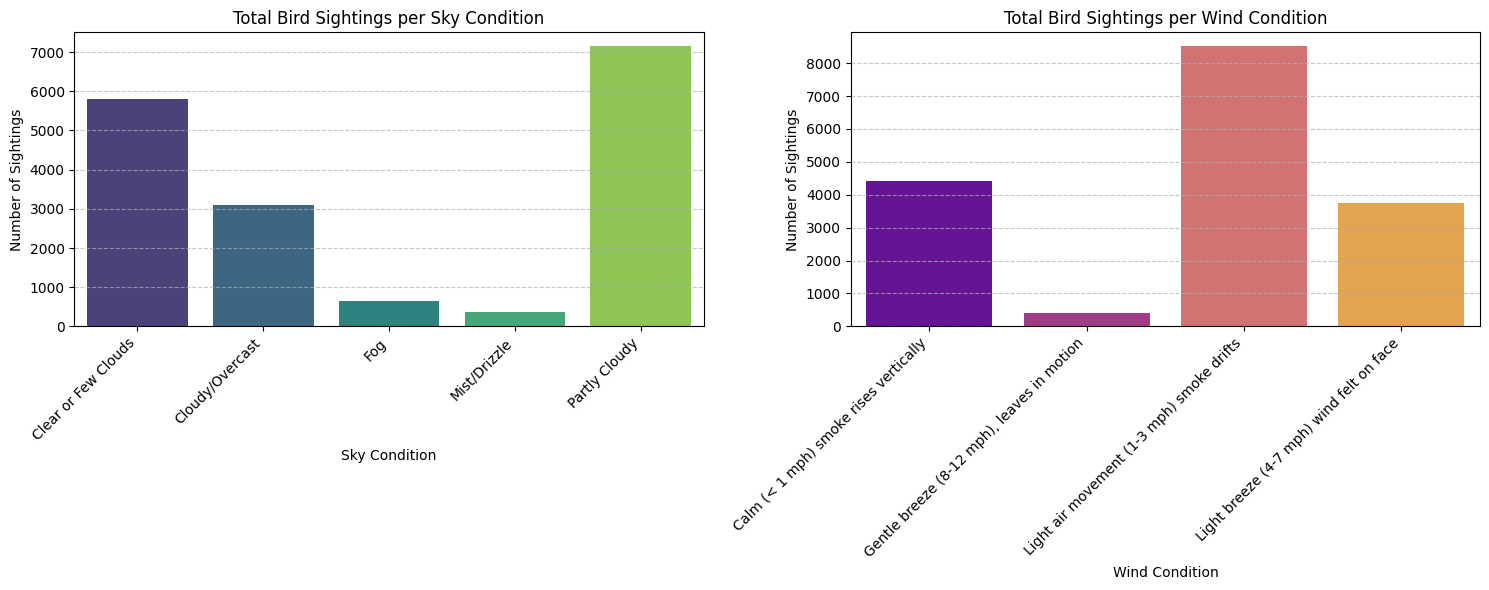

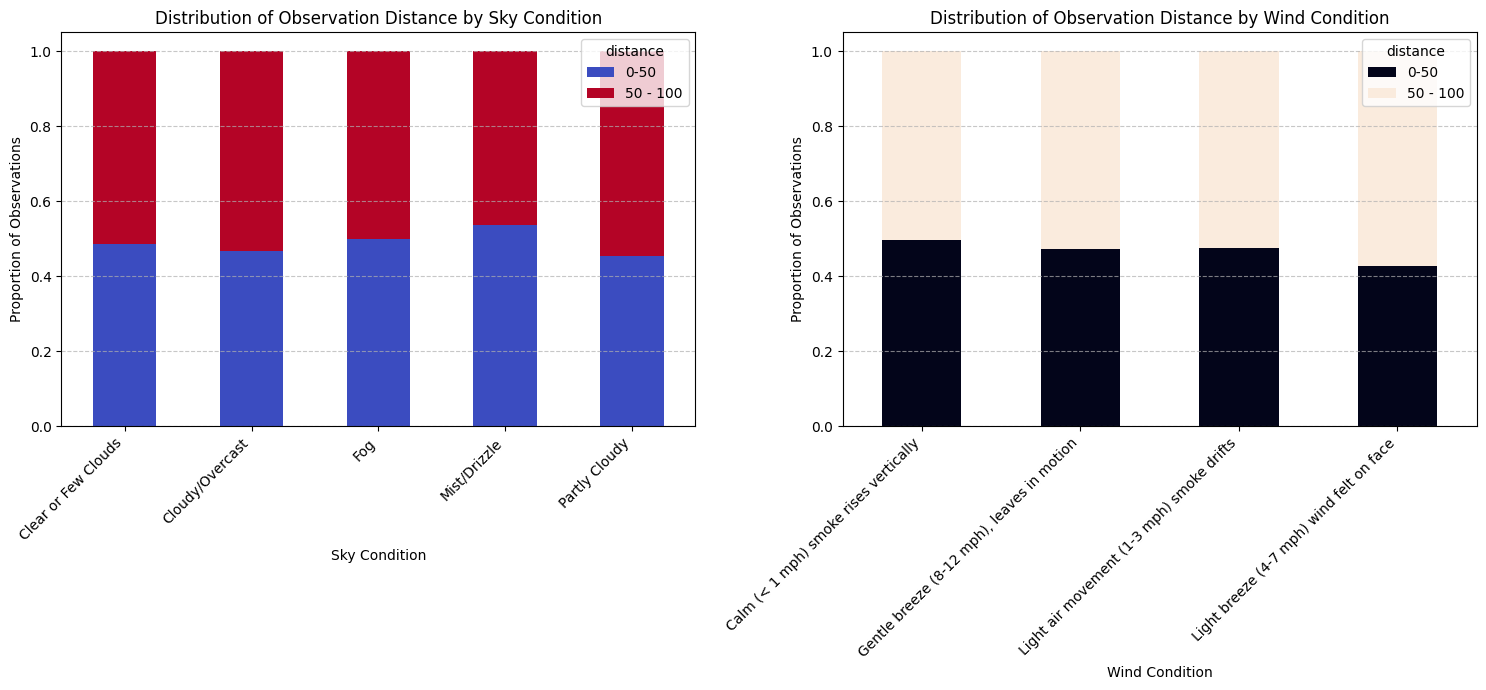

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Plot 1: Bird Sightings by Sky Condition
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sky_sightings = df_cleaned.groupby('sky', observed=True).size().reset_index(name='count')
sns.barplot(x='sky', y='count', data=sky_sightings, palette='viridis', hue='sky', legend=False)
plt.title('Total Bird Sightings per Sky Condition')
plt.xlabel('Sky Condition')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Bird Sightings by Wind Condition
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
wind_sightings = df_cleaned.groupby('wind', observed=True).size().reset_index(name='count')
sns.barplot(x='wind', y='count', data=wind_sightings, palette='plasma', hue='wind', legend=False)
plt.title('Total Bird Sightings per Wind Condition')
plt.xlabel('Wind Condition')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plotting distribution of 'distance' for sky conditions
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
distance_sky_crosstab = pd.crosstab(df_cleaned['sky'], df_cleaned['distance'], normalize='index')
distance_sky_crosstab.plot(kind='bar', stacked=True, colormap='coolwarm', ax=plt.gca())
plt.title('Distribution of Observation Distance by Sky Condition')
plt.xlabel('Sky Condition')
plt.ylabel('Proportion of Observations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plotting distribution of 'distance' for wind conditions
plt.subplot(1, 2, 2)
distance_wind_crosstab = pd.crosstab(df_cleaned['wind'], df_cleaned['distance'], normalize='index')
distance_wind_crosstab.plot(kind='bar', stacked=True, colormap='rocket', ax=plt.gca())
plt.title('Distribution of Observation Distance by Wind Condition')
plt.xlabel('Wind Condition')
plt.ylabel('Proportion of Observations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Disturbance Effect

### Distance and Behavior Analysis

#### Distance Analysis: Species Observed Closer vs. Farther

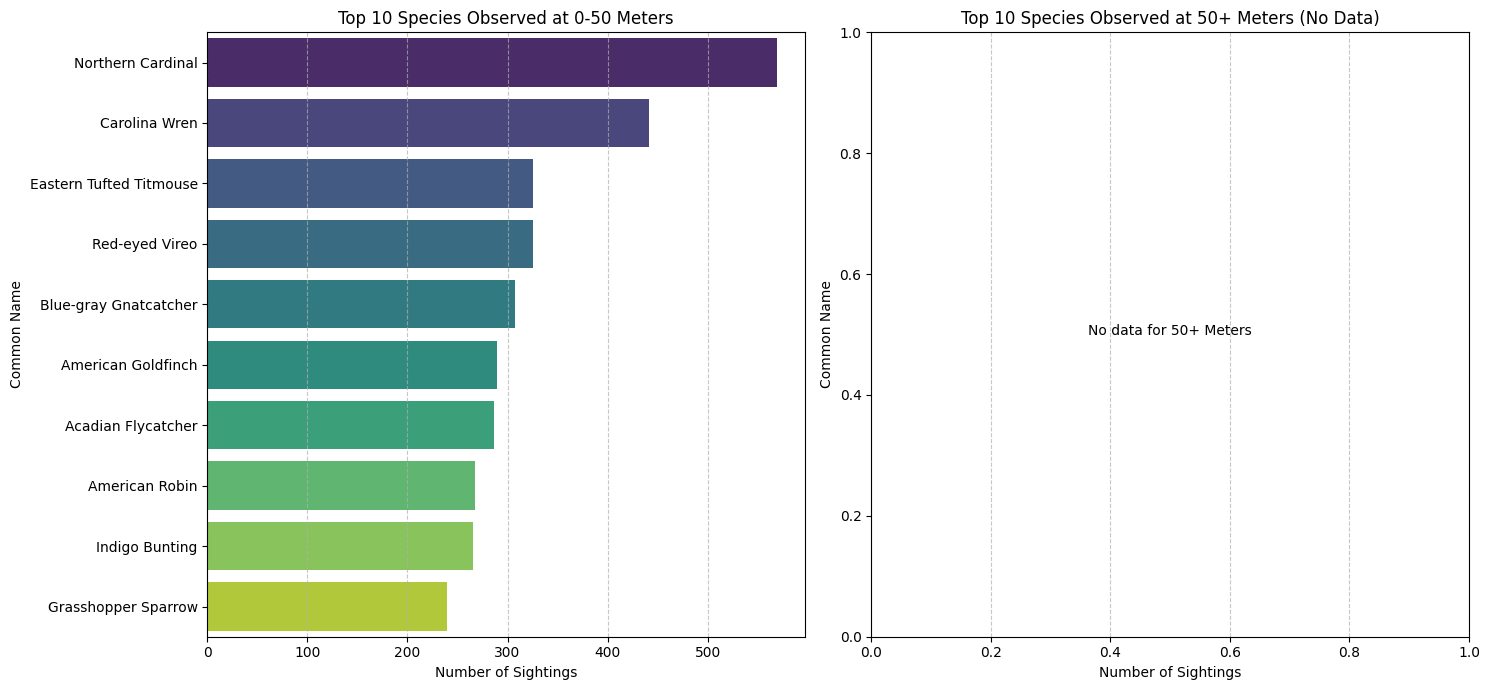

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze species by distance category
# For '0-50' meters
species_0_50 = df_cleaned[df_cleaned['distance'] == '0-50'].groupby('common_name', observed=True).size().reset_index(name='count')
species_0_50_top10 = species_0_50.sort_values(by='count', ascending=False).head(10).copy()
# Convert to string to ensure bars render correctly
species_0_50_top10['common_name'] = species_0_50_top10['common_name'].astype(str)

# For '50+' meters
species_50_plus = df_cleaned[df_cleaned['distance'] == '50+'].groupby('common_name', observed=True).size().reset_index(name='count')
species_50_plus_top10 = species_50_plus.sort_values(by='count', ascending=False).head(10).copy()
# Convert to string to ensure bars render correctly
species_50_plus_top10['common_name'] = species_50_plus_top10['common_name'].astype(str)

plt.figure(figsize=(15, 7))

# Plot for '0-50' meters
plt.subplot(1, 2, 1)
sns.barplot(x='count', y='common_name', data=species_0_50_top10, palette='viridis', hue='common_name', legend=False)
plt.title('Top 10 Species Observed at 0-50 Meters')
plt.xlabel('Number of Sightings')
plt.ylabel('Common Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot for '50+' meters
plt.subplot(1, 2, 2)
if not species_50_plus_top10.empty:
    sns.barplot(x='count', y='common_name', data=species_50_plus_top10, palette='plasma', hue='common_name', legend=False)
    plt.title('Top 10 Species Observed at 50+ Meters')
else:
    plt.text(0.5, 0.5, 'No data for 50+ Meters', ha='center')
    plt.title('Top 10 Species Observed at 50+ Meters (No Data)')

plt.xlabel('Number of Sightings')
plt.ylabel('Common Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Flyover Frequency: Trends in Bird Behavior

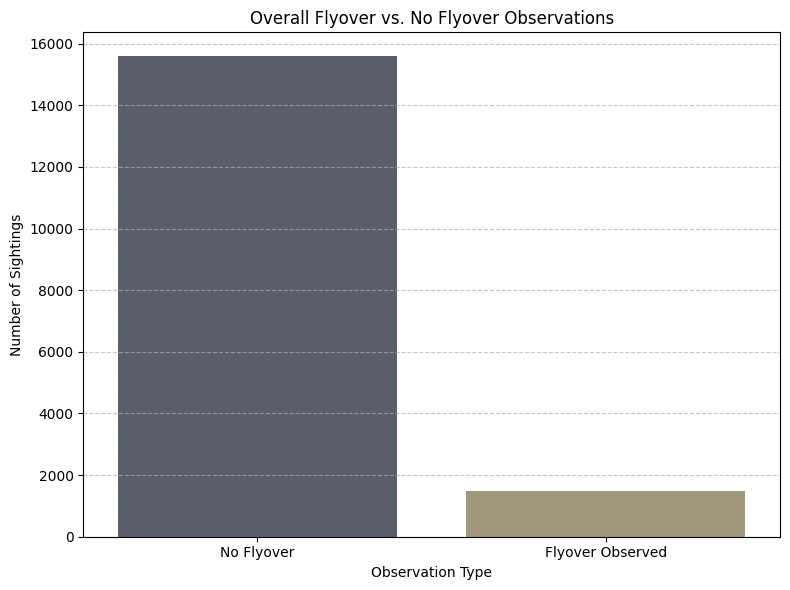

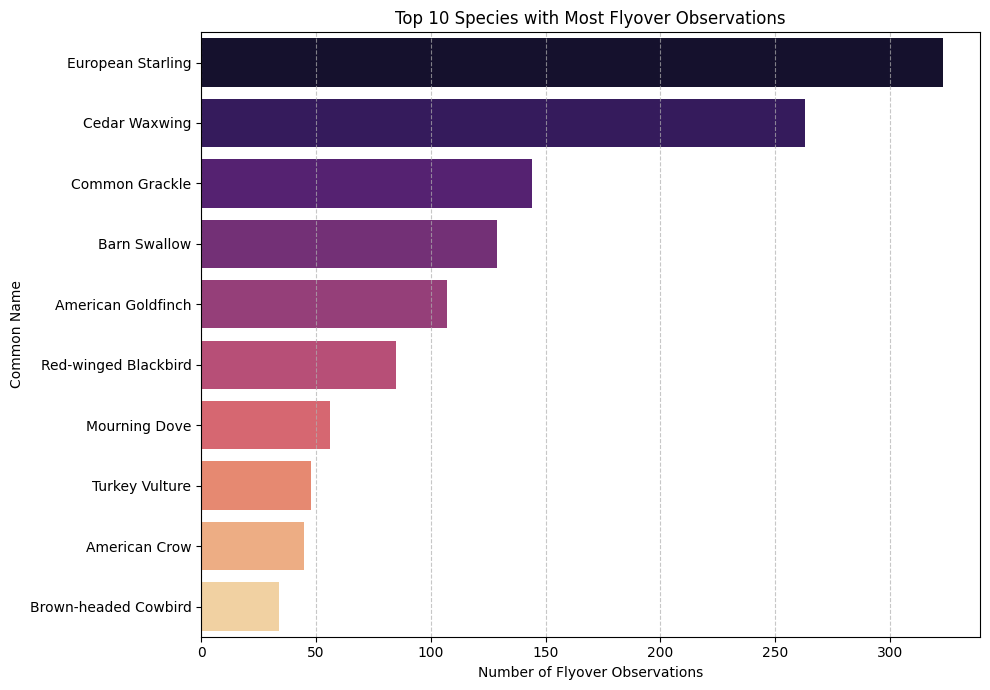

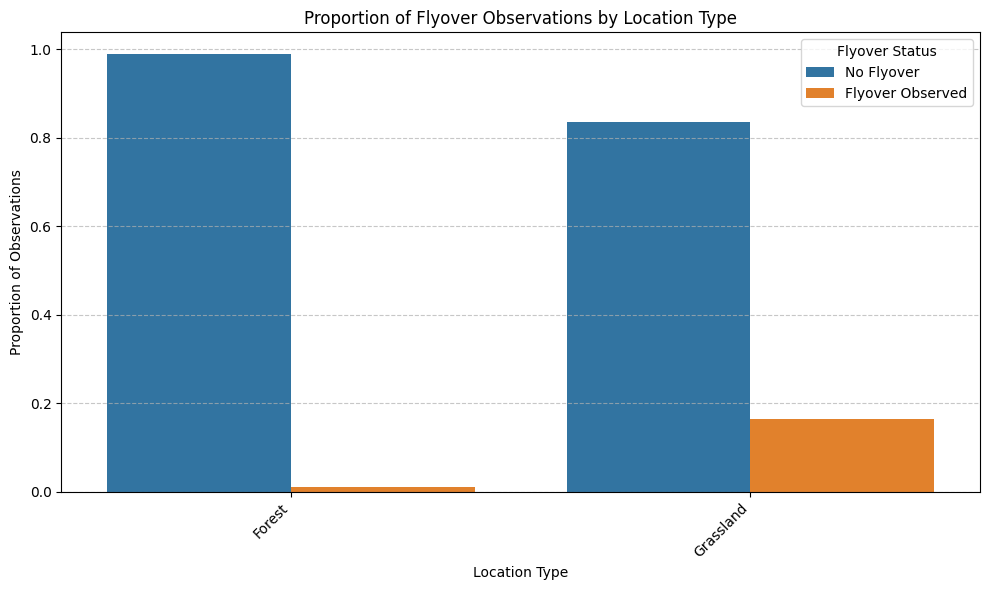

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Overall flyover frequency
flyover_counts = df_cleaned['flyover_observed'].value_counts().reset_index()
flyover_counts.columns = ['flyover_observed', 'count']
flyover_counts['flyover_observed'] = flyover_counts['flyover_observed'].map({1: 'Flyover Observed', 0: 'No Flyover'})

plt.figure(figsize=(8, 6))
sns.barplot(x='flyover_observed', y='count', data=flyover_counts, palette='cividis', hue='flyover_observed', legend=False)
plt.title('Overall Flyover vs. No Flyover Observations')
plt.xlabel('Observation Type')
plt.ylabel('Number of Sightings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Flyover frequency per species (top 10 species with most flyovers)
species_flyovers = df_cleaned[df_cleaned['flyover_observed'] == 1].groupby('common_name', observed=True).size().reset_index(name='flyover_count')

# Fix: Filter out zero counts and convert to string to ensure bars render
species_flyovers = species_flyovers[species_flyovers['flyover_count'] > 0]
species_flyovers['common_name'] = species_flyovers['common_name'].astype(str)

species_flyovers_top10 = species_flyovers.sort_values(by='flyover_count', ascending=False).head(10)

plt.figure(figsize=(10, 7))
sns.barplot(x='flyover_count', y='common_name', data=species_flyovers_top10, palette='magma', hue='common_name', legend=False)
plt.title('Top 10 Species with Most Flyover Observations')
plt.xlabel('Number of Flyover Observations')
plt.ylabel('Common Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Flyover frequency by location type
flyover_by_location = df_cleaned.groupby('location_type', observed=True)['flyover_observed'].value_counts(normalize=True).unstack().reset_index()
flyover_by_location.columns = ['location_type', 'no_flyover_prop', 'flyover_prop']

# Prepare data for stacked bar plot
flyover_by_location_melted = flyover_by_location.melt(id_vars='location_type', var_name='Observation Type', value_name='Proportion')
flyover_by_location_melted['Observation Type'] = flyover_by_location_melted['Observation Type'].map({'no_flyover_prop': 'No Flyover', 'flyover_prop': 'Flyover Observed'})

plt.figure(figsize=(10, 6))
sns.barplot(x='location_type', y='Proportion', hue='Observation Type', data=flyover_by_location_melted, palette='tab10')
plt.title('Proportion of Flyover Observations by Location Type')
plt.xlabel('Location Type')
plt.ylabel('Proportion of Observations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Flyover Status')
plt.tight_layout()
plt.show()

In [56]:
from google.colab import files

# Save the cleaned dataframe to a CSV file
df_cleaned.to_csv('cleaned_bird_data.csv', index=False)

# Download the file to your local machine
files.download('cleaned_bird_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Observer Trends

#### Observer Bias: Observation Counts and Unique Species by Observer

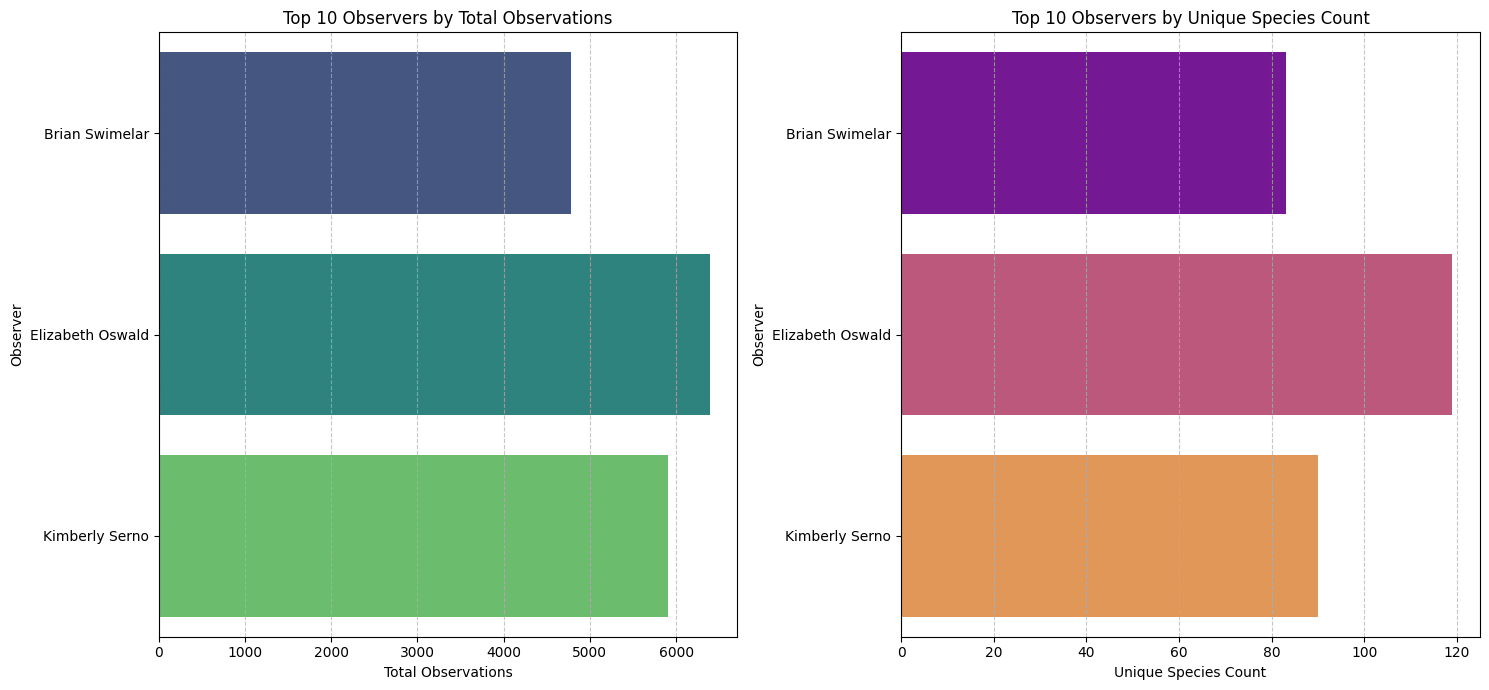

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by observer and count total observations
observer_counts = df_cleaned.groupby('observer', observed=True).size().reset_index(name='total_observations')
observer_counts_top10 = observer_counts.sort_values(by='total_observations', ascending=False).head(10)

# Group by observer and count unique species
observer_unique_species = df_cleaned.groupby('observer', observed=True)['common_name'].nunique().reset_index(name='unique_species_count')
observer_unique_species_top10 = observer_unique_species.sort_values(by='unique_species_count', ascending=False).head(10)

plt.figure(figsize=(15, 7))

# Plot 1: Total Observations by Observer
plt.subplot(1, 2, 1)
sns.barplot(x='total_observations', y='observer', data=observer_counts_top10, palette='viridis', hue='observer', legend=False)
plt.title('Top 10 Observers by Total Observations')
plt.xlabel('Total Observations')
plt.ylabel('Observer')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot 2: Unique Species Count by Observer
plt.subplot(1, 2, 2)
sns.barplot(x='unique_species_count', y='observer', data=observer_unique_species_top10, palette='plasma', hue='observer', legend=False)
plt.title('Top 10 Observers by Unique Species Count')
plt.xlabel('Unique Species Count')
plt.ylabel('Observer')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Visit Patterns: Impact on Species Count or Diversity

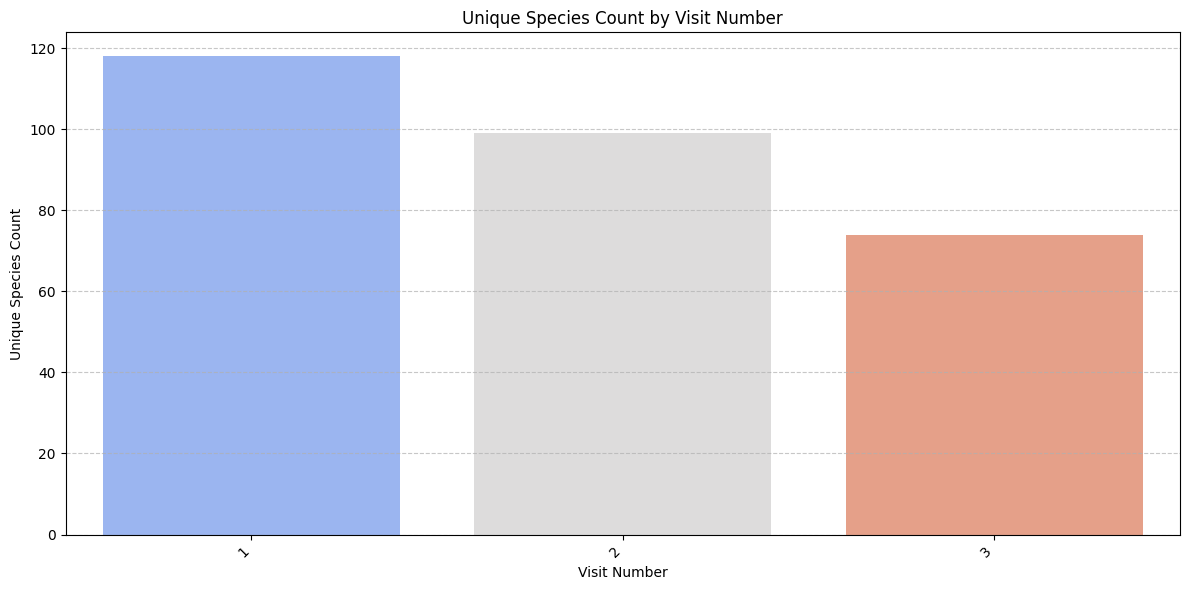

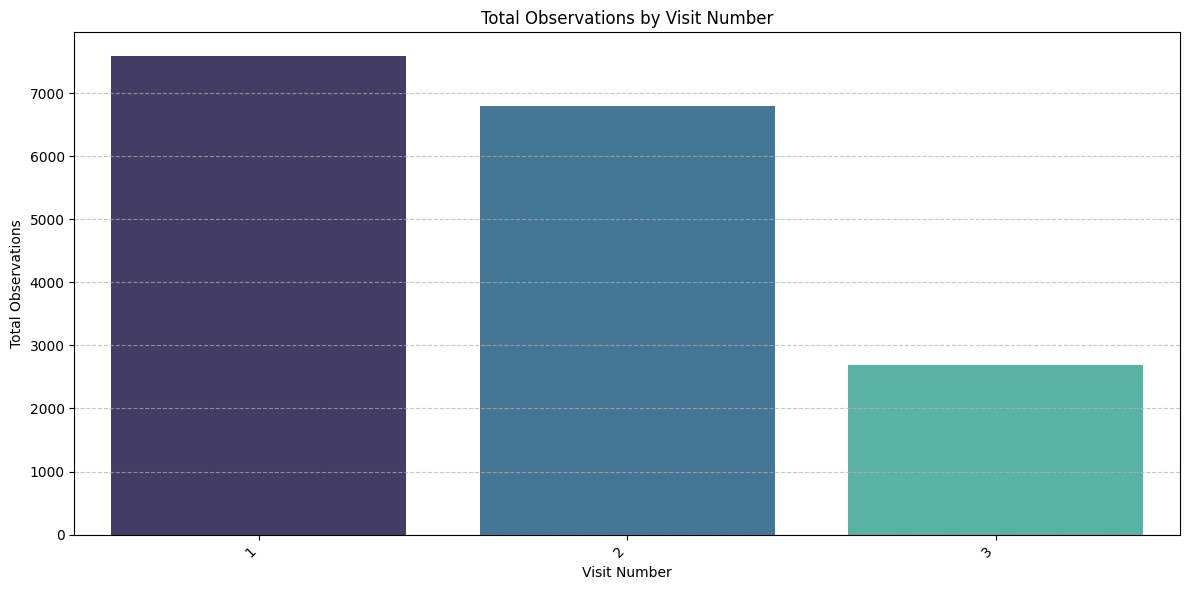

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by visit and count unique species
visit_unique_species = df_cleaned.groupby('visit', observed=True)['common_name'].nunique().reset_index(name='unique_species_count')

# Sort by unique species count for better visualization
visit_unique_species_sorted = visit_unique_species.sort_values(by='unique_species_count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='visit', y='unique_species_count', data=visit_unique_species_sorted, palette='coolwarm', hue='visit', legend=False)
plt.title('Unique Species Count by Visit Number')
plt.xlabel('Visit Number')
plt.ylabel('Unique Species Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Group by visit and count total observations
visit_total_observations = df_cleaned.groupby('visit', observed=True).size().reset_index(name='total_observations')
visit_total_observations_sorted = visit_total_observations.sort_values(by='total_observations', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='visit', y='total_observations', data=visit_total_observations_sorted, palette='mako', hue='visit', legend=False)
plt.title('Total Observations by Visit Number')
plt.xlabel('Visit Number')
plt.ylabel('Total Observations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Conservation Insights

#### Watchlist Trends: Species at Risk

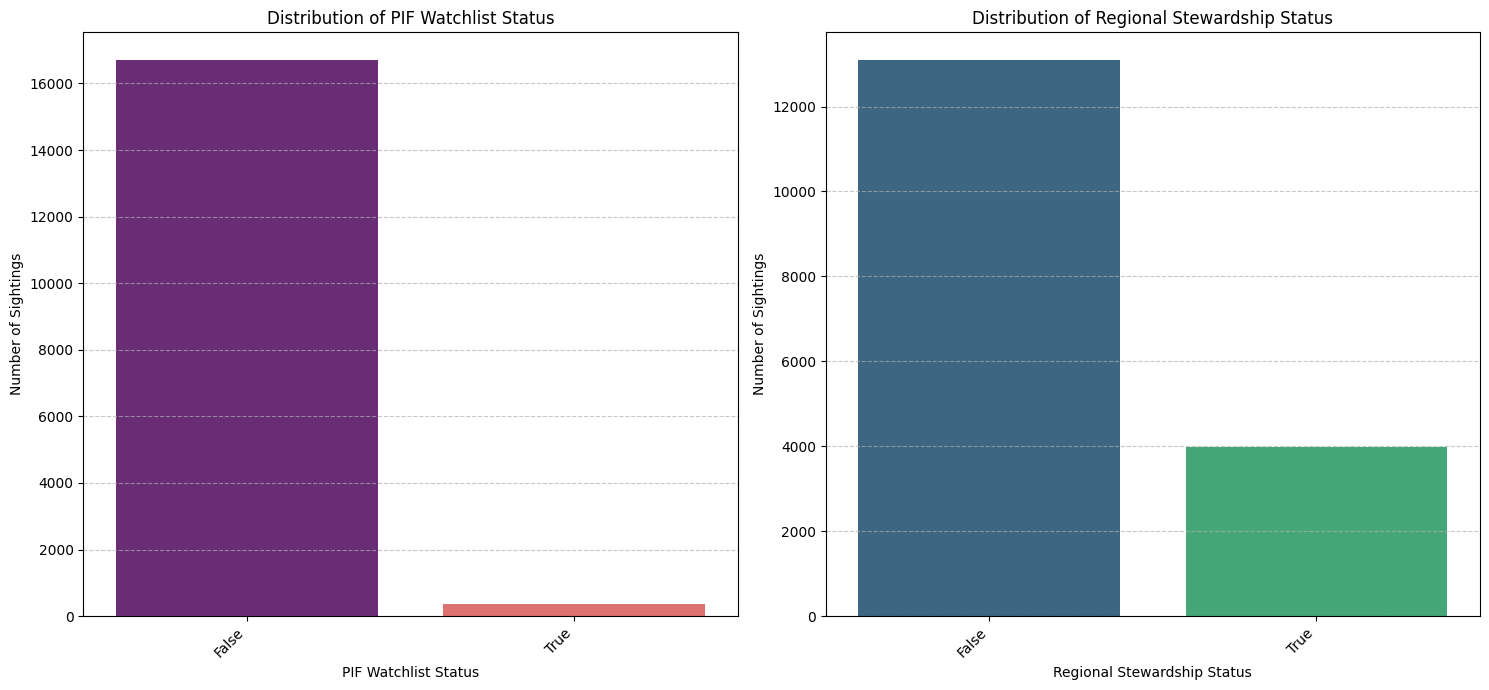

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))

# Plot 1: Distribution of PIF Watchlist Status
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
pif_status_counts = df_cleaned.groupby('pif_watchlist_status', observed=True).size().reset_index(name='count')
sns.barplot(x='pif_watchlist_status', y='count', data=pif_status_counts, palette='magma', hue='pif_watchlist_status', legend=False)
plt.title('Distribution of PIF Watchlist Status')
plt.xlabel('PIF Watchlist Status')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Distribution of Regional Stewardship Status
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
regional_status_counts = df_cleaned.groupby('regional_stewardship_status', observed=True).size().reset_index(name='count')
sns.barplot(x='regional_stewardship_status', y='count', data=regional_status_counts, palette='viridis', hue='regional_stewardship_status', legend=False)
plt.title('Distribution of Regional Stewardship Status')
plt.xlabel('Regional Stewardship Status')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### AOU Code Patterns: Distribution and Potential Priorities

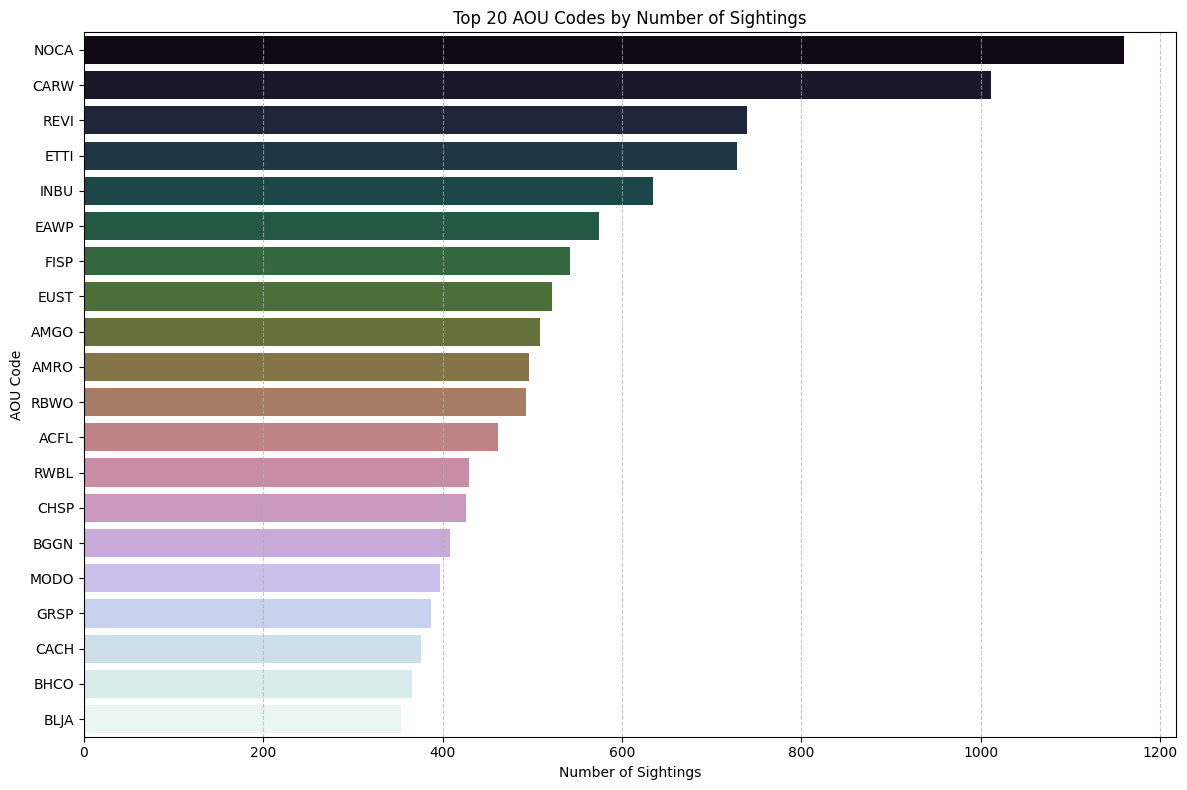

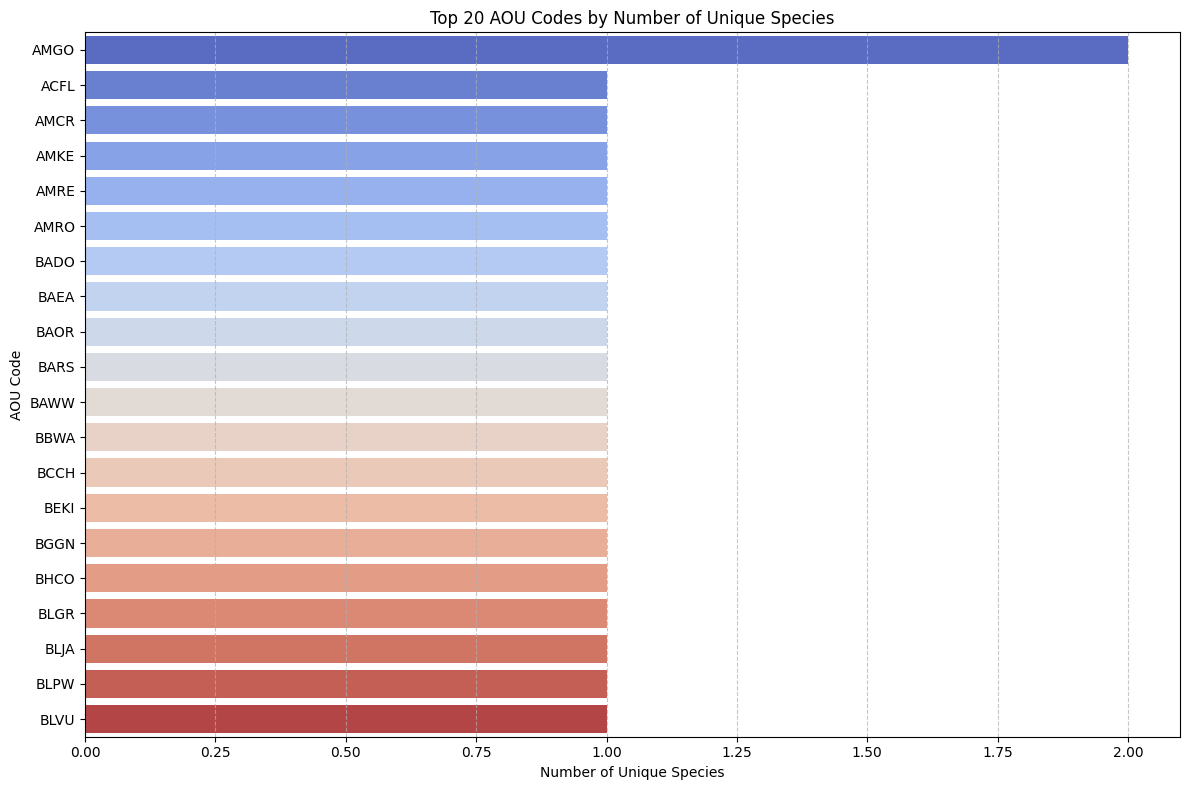

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each AOU_Code
aou_code_counts = df_cleaned.groupby('aou_code', observed=True).size().reset_index(name='count')

# Filter out zero counts and convert to string to avoid categorical plotting issues
aou_code_counts = aou_code_counts[aou_code_counts['count'] > 0]
aou_code_counts['aou_code'] = aou_code_counts['aou_code'].astype(str)

# Sort by count and display top 20
aou_code_counts_top20 = aou_code_counts.sort_values(by='count', ascending=False).head(20)

if not aou_code_counts_top20.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(x='count', y='aou_code', data=aou_code_counts_top20, palette='cubehelix', hue='aou_code', legend=False)
    plt.title('Top 20 AOU Codes by Number of Sightings')
    plt.xlabel('Number of Sightings')
    plt.ylabel('AOU Code')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Warning: No valid AOU Code data found to plot sightings.")

# Analyze unique species per AOU code
unique_species_per_aou = df_cleaned.groupby('aou_code', observed=True)['scientific_name'].nunique().reset_index(name='unique_species_count')

# Filter and convert to string
unique_species_per_aou = unique_species_per_aou[unique_species_per_aou['unique_species_count'] > 0]
unique_species_per_aou['aou_code'] = unique_species_per_aou['aou_code'].astype(str)

unique_species_per_aou_top20 = unique_species_per_aou.sort_values(by='unique_species_count', ascending=False).head(20)

if not unique_species_per_aou_top20.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(x='unique_species_count', y='aou_code', data=unique_species_per_aou_top20, palette='coolwarm', hue='aou_code', legend=False)
    plt.title('Top 20 AOU Codes by Number of Unique Species')
    plt.xlabel('Number of Unique Species')
    plt.ylabel('AOU Code')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Warning: No valid AOU Code data found to plot unique species.")

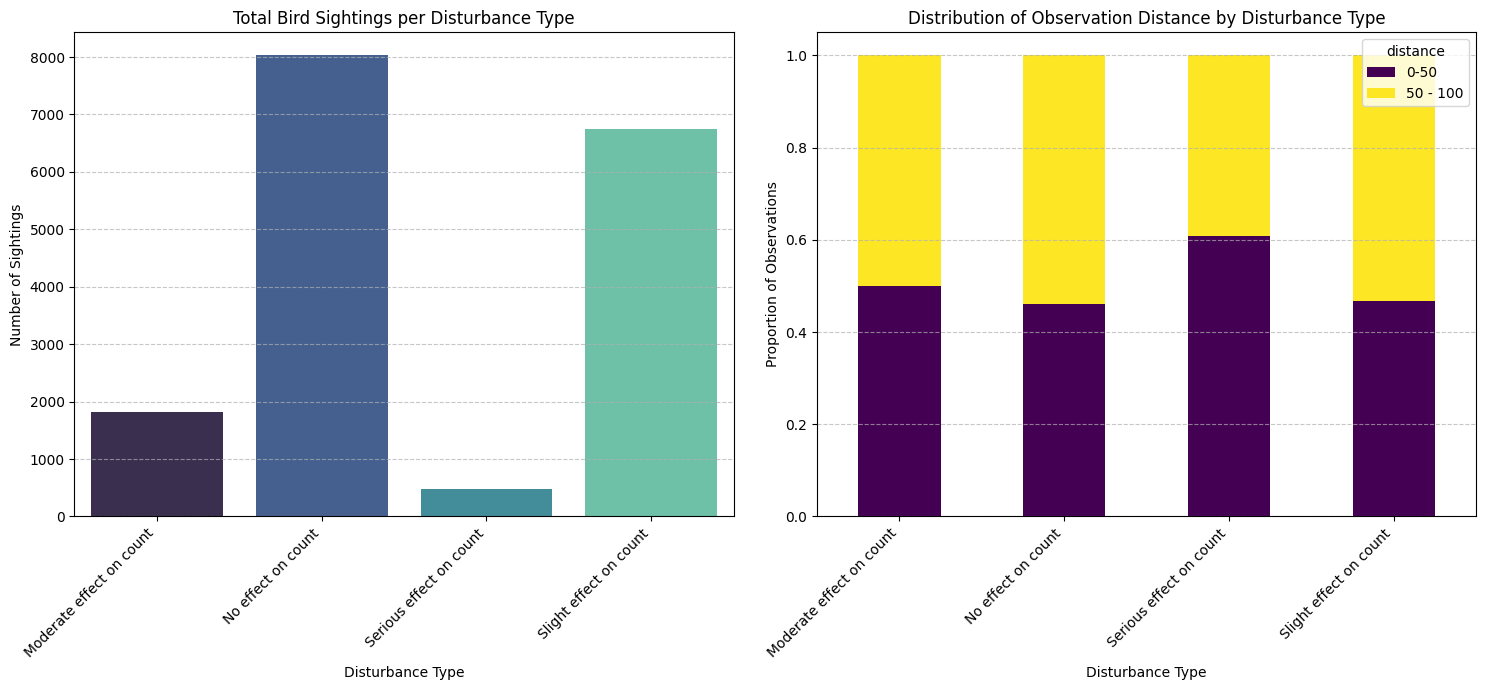

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))

# Plot 1: Bird Sightings by Disturbance Type
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
disturbance_sightings = df_cleaned.groupby('disturbance', observed=True).size().reset_index(name='count')
sns.barplot(x='disturbance', y='count', data=disturbance_sightings, palette='mako', hue='disturbance', legend=False)
plt.title('Total Bird Sightings per Disturbance Type')
plt.xlabel('Disturbance Type')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Distribution of 'distance' for disturbance types
plt.subplot(1, 2, 2)
distance_disturbance_crosstab = pd.crosstab(df_cleaned['disturbance'], df_cleaned['distance'], normalize='index')
distance_disturbance_crosstab.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Distribution of Observation Distance by Disturbance Type')
plt.xlabel('Disturbance Type')
plt.ylabel('Proportion of Observations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()